Total transects generated: 795

--- DIAGNOSTIC CHECK ---
Valid d14: 791
Valid d19: 0
Valid d24: 791
Transects used for plotting: 791


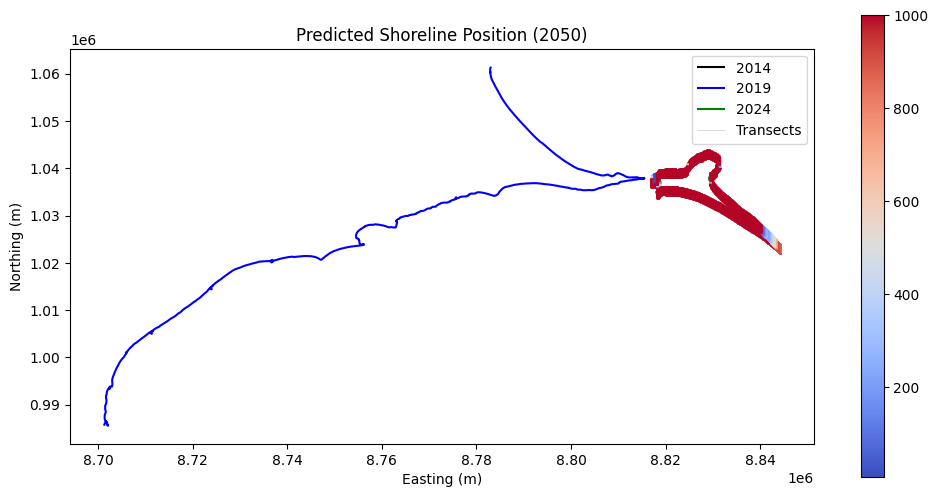

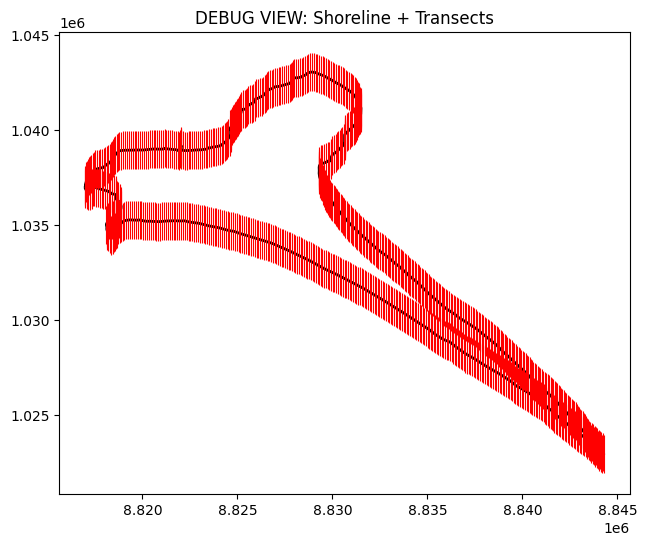

✅ Analysis complete. Outputs saved.


/tmp/ipython-input-3927869924.py:138: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  transects_clean.to_file("/content/predicted_shoreline_2050.shp")
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'predicted_2050' to 'predicted_'
  ogr_write(


In [ ]:
# =========================================================
# SHORELINE CHANGE + 2050 PREDICTION
# WITH EMPTY-PLOT DIAGNOSTIC & FIX
# =========================================================

# ---------- 1. IMPORT LIBRARIES ----------
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

# ---------- 2. READ SHAPEFILES ----------
sh14 = gpd.read_file("/content/2014-d.shp")
sh19 = gpd.read_file("/content/2019_d.shp")
sh24 = gpd.read_file("/content/2024_d.shp")

# ---------- 3. CRS HANDLING ----------
sh19 = sh19.to_crs(sh14.crs)
sh24 = sh24.to_crs(sh14.crs)

if sh14.crs.is_geographic:
    target_crs = "EPSG:3857"  # meters
    sh14 = sh14.to_crs(target_crs)
    sh19 = sh19.to_crs(target_crs)
    sh24 = sh24.to_crs(target_crs)

# ---------- 4. BASELINE ----------
baseline = sh14.geometry.union_all() # Updated from unary_union

# ---------- 5. TRANSECT GENERATION ----------
transects = []
spacing = 100     # meters
length = 2000     # increased length to ensure intersection

lines = baseline.geoms if baseline.geom_type == "MultiLineString" else [baseline]

for line in lines:
    for d in np.arange(0, line.length, spacing):
        p = line.interpolate(d)

        transect = LineString([
            (p.x, p.y - length / 2),
            (p.x, p.y + length / 2)
        ])
        transects.append(transect)

transects_gdf = gpd.GeoDataFrame(geometry=transects, crs=sh14.crs)

print("Total transects generated:", len(transects_gdf))

# ---------- 6. INTERSECTION DISTANCE FUNCTION ----------
def intersect_distance(transect, shoreline):
    inter = transect.intersection(shoreline.geometry.union_all()) # Updated from unary_union

    if inter.is_empty:
        return np.nan

    start = Point(transect.coords[0])

    if inter.geom_type == "Point":
        return start.distance(inter)

    if inter.geom_type == "MultiPoint":
        return min(start.distance(pt) for pt in inter.geoms)

    return np.nan

# ---------- 7. DISTANCE CALCULATION ----------
transects_gdf["d14"] = transects_gdf.geometry.apply(lambda x: intersect_distance(x, sh14)).astype(float)
transects_gdf["d19"] = transects_gdf.geometry.apply(lambda x: intersect_distance(x, sh19)).astype(float)
transects_gdf["d24"] = transects_gdf.geometry.apply(lambda x: intersect_distance(x, sh24)).astype(float)

# ---------- 8. DIAGNOSTIC CHECK (CRITICAL) ----------
print("\n--- DIAGNOSTIC CHECK ---")
print("Valid d14:", transects_gdf["d14"].notna().sum())
print("Valid d19:", transects_gdf["d19"].notna().sum())
print("Valid d24:", transects_gdf["d24"].notna().sum())

# ---------- 9. LRR & 2050 PREDICTION ----------
years = np.array([2014, 2019, 2024])

def compute_lrr(row):
    dists = row[["d14", "d19", "d24"]].values.astype(float) # Explicitly cast to float array here
    mask = ~np.isnan(dists)
    if mask.sum() < 2:
        return np.nan
    coef = np.polyfit(years[mask], dists[mask], 1)
    return coef[0]

transects_gdf["LRR"] = transects_gdf.apply(compute_lrr, axis=1)
transects_gdf["predicted_2050"] = transects_gdf["d24"] + transects_gdf["LRR"] * (2050 - 2024)

# ---------- 10. SAFE FILTER (FIX FOR EMPTY PLOT) ----------
transects_clean = transects_gdf[
    transects_gdf["predicted_2050"].notna()
].copy()

print("Transects used for plotting:", len(transects_clean))

# ---------- 11. MAIN MAP (WILL SHOW CONTENT) ----------
fig, ax = plt.subplots(figsize=(12, 6))

sh14.plot(ax=ax, color="black", linewidth=1.5, label="2014")
sh19.plot(ax=ax, color="blue", linewidth=1.5, label="2019")
sh24.plot(ax=ax, color="green", linewidth=1.5, label="2024")

transects_gdf.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.6,
    label="Transects"
)

transects_clean.plot(
    ax=ax,
    column="predicted_2050",
    cmap="coolwarm",
    legend=True,
    linewidth=2
)

plt.title("Predicted Shoreline Position (2050)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.legend()
plt.show()

# ---------- 12. DEBUG PLOT (ALWAYS SHOWS SOMETHING) ----------
fig, ax = plt.subplots(figsize=(12, 6))
sh14.plot(ax=ax, color="black", linewidth=2)
transects_gdf.plot(ax=ax, color="red", linewidth=0.8)

plt.title("DEBUG VIEW: Shoreline + Transects")
plt.show()

# ---------- 13. SAVE OUTPUT ----------
transects_clean.to_file("/content/predicted_shoreline_2050.shp")
transects_clean.drop(columns="geometry").to_csv(
    "/content/predicted_shoreline_2050.csv",
    index=False
)

print("✅ Analysis complete. Outputs saved.")

Total transects generated: 795

--- DIAGNOSTIC CHECK ---
Valid d14: 791
Valid d19: 0
Valid d24: 791
Transects used for plotting: 791


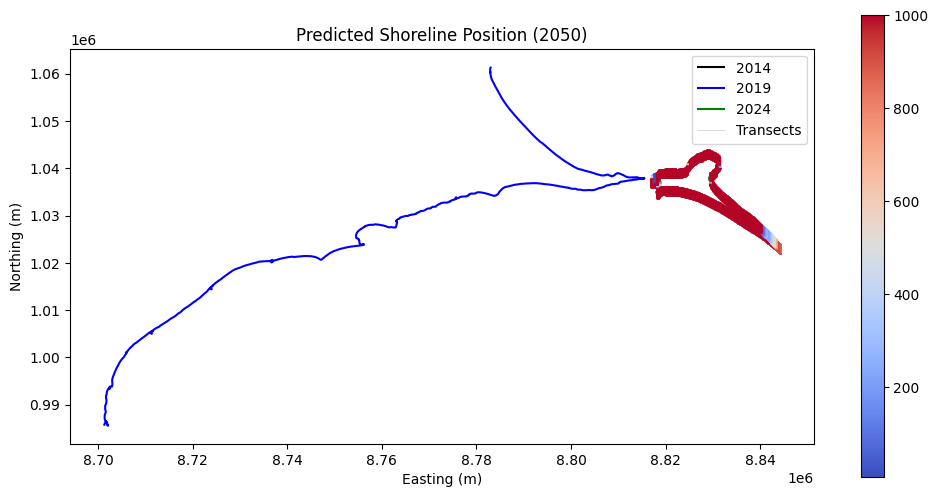

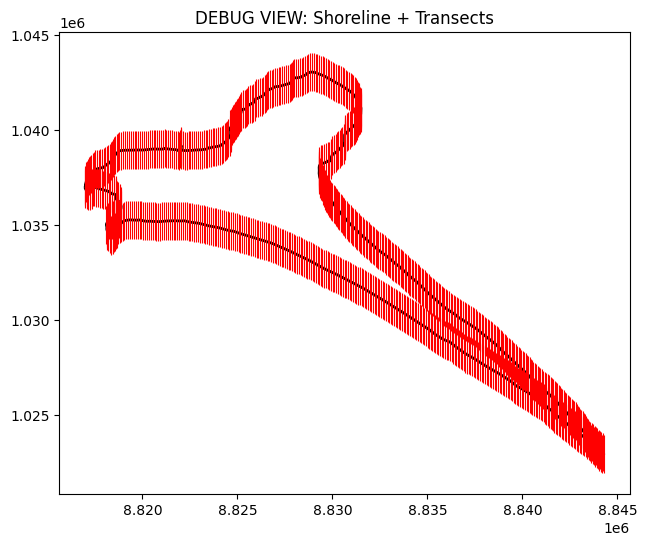

✅ Analysis complete. Outputs saved.


/tmp/ipython-input-3927869924.py:138: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  transects_clean.to_file("/content/predicted_shoreline_2050.shp")
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'predicted_2050' to 'predicted_'
  ogr_write(


In [20]:
# =========================================================
# SHORELINE CHANGE + 2050 PREDICTION
# WITH EMPTY-PLOT DIAGNOSTIC & FIX
# =========================================================

# ---------- 1. IMPORT LIBRARIES ----------
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

# ---------- 2. READ SHAPEFILES ----------
sh14 = gpd.read_file("/content/2014-d.shp")
sh19 = gpd.read_file("/content/2019_d.shp")
sh24 = gpd.read_file("/content/2024_d.shp")

# ---------- 3. CRS HANDLING ----------
sh19 = sh19.to_crs(sh14.crs)
sh24 = sh24.to_crs(sh14.crs)

if sh14.crs.is_geographic:
    target_crs = "EPSG:3857"  # meters
    sh14 = sh14.to_crs(target_crs)
    sh19 = sh19.to_crs(target_crs)
    sh24 = sh24.to_crs(target_crs)

# ---------- 4. BASELINE ----------
baseline = sh14.geometry.union_all() # Updated from unary_union

# ---------- 5. TRANSECT GENERATION ----------
transects = []
spacing = 100     # meters
length = 2000     # increased length to ensure intersection

lines = baseline.geoms if baseline.geom_type == "MultiLineString" else [baseline]

for line in lines:
    for d in np.arange(0, line.length, spacing):
        p = line.interpolate(d)

        transect = LineString([
            (p.x, p.y - length / 2),
            (p.x, p.y + length / 2)
        ])
        transects.append(transect)

transects_gdf = gpd.GeoDataFrame(geometry=transects, crs=sh14.crs)

print("Total transects generated:", len(transects_gdf))

# ---------- 6. INTERSECTION DISTANCE FUNCTION ----------
def intersect_distance(transect, shoreline):
    inter = transect.intersection(shoreline.geometry.union_all()) # Updated from unary_union

    if inter.is_empty:
        return np.nan

    start = Point(transect.coords[0])

    if inter.geom_type == "Point":
        return start.distance(inter)

    if inter.geom_type == "MultiPoint":
        return min(start.distance(pt) for pt in inter.geoms)

    return np.nan

# ---------- 7. DISTANCE CALCULATION ----------
transects_gdf["d14"] = transects_gdf.geometry.apply(lambda x: intersect_distance(x, sh14)).astype(float)
transects_gdf["d19"] = transects_gdf.geometry.apply(lambda x: intersect_distance(x, sh19)).astype(float)
transects_gdf["d24"] = transects_gdf.geometry.apply(lambda x: intersect_distance(x, sh24)).astype(float)

# ---------- 8. DIAGNOSTIC CHECK (CRITICAL) ----------
print("\n--- DIAGNOSTIC CHECK ---")
print("Valid d14:", transects_gdf["d14"].notna().sum())
print("Valid d19:", transects_gdf["d19"].notna().sum())
print("Valid d24:", transects_gdf["d24"].notna().sum())

# ---------- 9. LRR & 2050 PREDICTION ----------
years = np.array([2014, 2019, 2024])

def compute_lrr(row):
    dists = row[["d14", "d19", "d24"]].values.astype(float) # Explicitly cast to float array here
    mask = ~np.isnan(dists)
    if mask.sum() < 2:
        return np.nan
    coef = np.polyfit(years[mask], dists[mask], 1)
    return coef[0]

transects_gdf["LRR"] = transects_gdf.apply(compute_lrr, axis=1)
transects_gdf["predicted_2050"] = transects_gdf["d24"] + transects_gdf["LRR"] * (2050 - 2024)

# ---------- 10. SAFE FILTER (FIX FOR EMPTY PLOT) ----------
transects_clean = transects_gdf[
    transects_gdf["predicted_2050"].notna()
].copy()

print("Transects used for plotting:", len(transects_clean))

# ---------- 11. MAIN MAP (WILL SHOW CONTENT) ----------
fig, ax = plt.subplots(figsize=(12, 6))

sh14.plot(ax=ax, color="black", linewidth=1.5, label="2014")
sh19.plot(ax=ax, color="blue", linewidth=1.5, label="2019")
sh24.plot(ax=ax, color="green", linewidth=1.5, label="2024")

transects_gdf.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.6,
    label="Transects"
)

transects_clean.plot(
    ax=ax,
    column="predicted_2050",
    cmap="coolwarm",
    legend=True,
    linewidth=2
)

plt.title("Predicted Shoreline Position (2050)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.legend()
plt.show()

# ---------- 12. DEBUG PLOT (ALWAYS SHOWS SOMETHING) ----------
fig, ax = plt.subplots(figsize=(12, 6))
sh14.plot(ax=ax, color="black", linewidth=2)
transects_gdf.plot(ax=ax, color="red", linewidth=0.8)

plt.title("DEBUG VIEW: Shoreline + Transects")
plt.show()

# ---------- 13. SAVE OUTPUT ----------
transects_clean.to_file("/content/predicted_shoreline_2050.shp")
transects_clean.drop(columns="geometry").to_csv(
    "/content/predicted_shoreline_2050.csv",
    index=False
)

print("✅ Analysis complete. Outputs saved.")